# Benchmark: Reproducing SI WIMP limits from XENONnT & LZ

In [1]:
import os
import diamx
from diamx.utils import generate_bin_array
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

diamx_dir = os.path.dirname(diamx.__file__)

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="appletree.config")
warnings.filterwarnings("ignore", category=UserWarning, module="appletree.component")

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles


## 0. Generate Input WIMP spectrum

Using package wimprates

In [2]:
import wimprates

energies = np.linspace(0.01, 100, 200)
wimp_masses = (
    list(range(6, 130, 2)) + list(range(130, 400, 10)) + [400, 500, 600, 800, 1000]
)
wimp_masses += list(range(100, 1000, 50)) + [1000, 2500, 5000, 10000]
wimp_masses = set(wimp_masses)
spectrum_data = np.zeros((len(energies), 2))
spectrum_data[:, 0] = energies
os.makedirs("./diamx_output/spectrum", exist_ok=True)
for wimp_mass in wimp_masses:
    spectrum_csv_fpath = os.path.join(
        "./diamx_output", "spectrum", f"wimp_{wimp_mass}GeV.csv"
    )
    spectrum_data[:, 1] = wimprates.rate_wimp_std(
        energies, mw=wimp_mass, sigma_nucleon=1e-44
    )
    np.savetxt(spectrum_csv_fpath, spectrum_data, delimiter=",")

/home/mhliu/miniconda3/envs/xenon/lib/python3.10/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(


## 1. XENONnT SR0

https://doi.org/10.1103/PhysRevLett.131.041003

Modelling: ER (flat spectrum), neutron

ROI: cs2 > 800PE (reduce the effect of AC & surface)

In [3]:
xenonnt_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config.json"),
)
xenonnt_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_st.generate_templates()

Generating background templates for xenonnt_sr0: 100%|██████████| 2/2 [00:00<00:00, 1259.17it/s]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [00:00<00:00, 1226.48it/s]


Text(0, 0.5, 'cS2 [PE]')

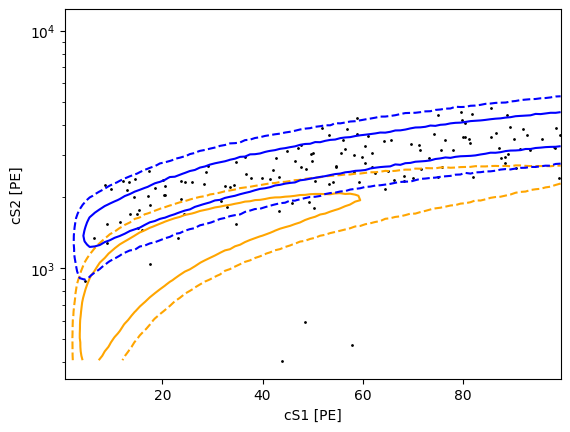

In [4]:
# Reproducing Fig. 3 (template distribution in cs1-cs2 space)
xenonnt_st.plot_signal_template(
    "xenonnt_sr0",
    200,
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["orange", "orange"], "linestyles": ["--", "-"]},
)
xenonnt_st.plot_bkg_template(
    "xenonnt_sr0",
    "er",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["blue", "blue"], "linestyles": ["--", "-"]},
)
data = xenonnt_st.experiment_instances[0].get_data()
plt.yscale("log")
plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
plt.xlabel("cS1 [PE]")
plt.ylabel("cS2 [PE]")

In [5]:
# Reproducing Table I (nominal & best-fit rate)
xenonnt_st.print_best_fit(200)

xenonnt_sr0
           Nominal   Best fit
er             134   134 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
Signal best fit: 3.3285144462268863



Running inference: 100%|██████████| 90/90 [00:57<00:00,  1.56it/s]


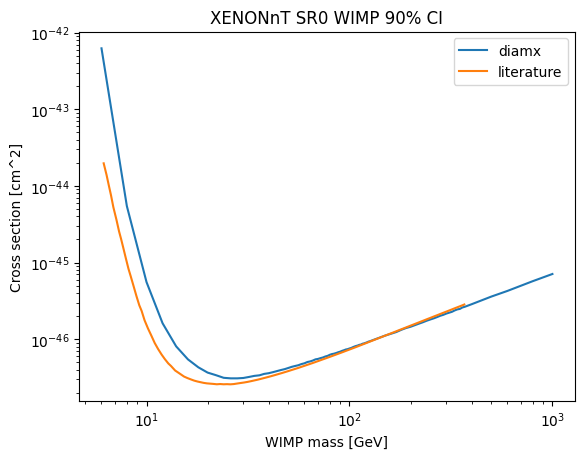

In [6]:
# Reproducing Fig. 4 (upper limit)
xenonnt_st.run_inference(output_file_name="xenonnt_sr0_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
# plt.savefig("xenonnt_sr1_wimp_ci.png", dpi=600)
plt.show()

## 2. LZ WS2022

DOI: https://doi.org/10.1103/PhysRevLett.131.041002

Modelling: beta+gamma (flat ER), neutrino (flat ER), 127Xe (5.2keV L-shell with 0.87 Q_L/Q_beta), 124Xe (5.98keV + 10keV), 37Ar (2.82keV)

In [7]:
lz_ws2022_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2022_wimp_config.json"),
)
lz_ws2022_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2022_st.generate_templates()

/home/mhliu/miniconda3/envs/xenon/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Generating background templates for lz_ws2022: 100%|██████████| 6/6 [04:39<00:00, 46.62s/it]/home/mhliu/miniconda3/envs/xenon/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()

Generating shaped background templates for lz_ws2022: 0it [00:00, ?it/s]
Generating signal templates for lz_ws2022: 100%|██████████| 67/67 [23:36<00:00, 21.14s/it]


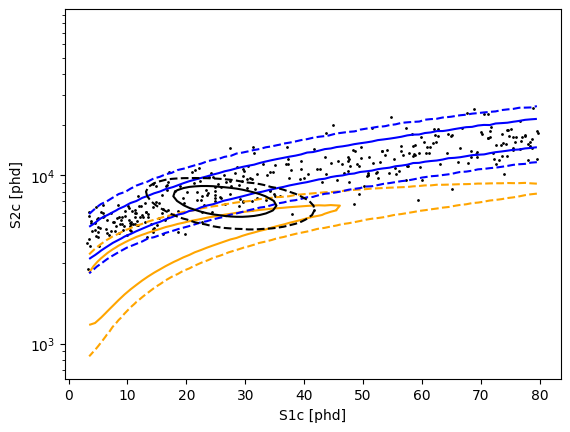

In [8]:
# Reproducing Fig. 4 (template distribution in S1c-logS2c space)
lz_ws2022_st.plot_signal_template(
    "lz_ws2022",
    200,
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["orange", "orange"], "linestyles": ["--", "-"]},
)
lz_ws2022_st.plot_bkg_template(
    "lz_ws2022",
    "beta",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["blue", "blue"], "linestyles": ["--", "-"]},
)
lz_ws2022_st.plot_bkg_template(
    "lz_ws2022",
    "xe127",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["k", "k"], "linestyles": ["--", "-"]},
)

data = lz_ws2022_st.experiment_instances[0].get_data()
plt.yscale("log")
plt.scatter(data["s1c"], data["s2c"], s=1, c="k")
plt.xlabel(r"S1c [phd]")
plt.ylabel(r"S2c [phd]")
plt.show()

In [9]:
# Reproducing Table I (nominal & best-fit rate)
lz_ws2022_st.print_best_fit(200)

lz_ws2022
             Nominal    Best fit
beta        220 ± 40    225 ± 16
neutrino  27.5 ± 1.6  27.5 ± 1.6
xe127      9.2 ± 0.8   9.3 ± 0.8
xe124      5.0 ± 1.4   5.3 ± 1.4
xe136         15 ± 2      15 ± 2
ar37              50      49 ± 9
Signal best fit: 0.0



Running inference: 100%|██████████| 67/67 [02:10<00:00,  1.95s/it]


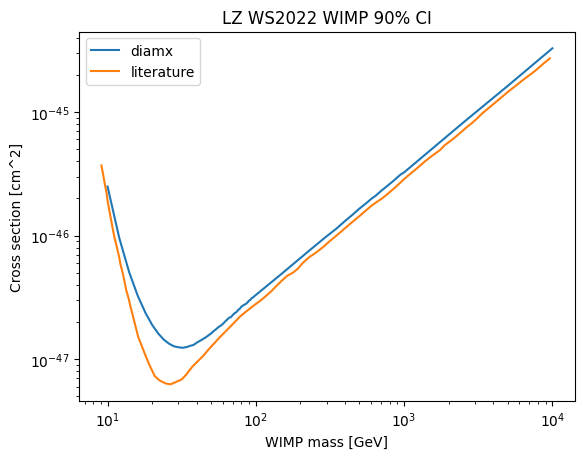

In [10]:
# Reproducing Fig. 5 (upper limit)
lz_ws2022_st.run_inference(output_file_name="lz_ws2022_wimp_ci_test.csv")
ci = np.loadtxt("./diamx_output/lz_ws2022_wimp_ci_test.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2022 WIMP 90% CI")
# plt.savefig("xenonnt_sr1_wimp_ci.png", dpi=600)
plt.show()

## 3. XENONnT combined SR0 & SR1

arXiv:2502.18005

In [11]:
xenonnt_sr01_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config.json"),
)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1b)
xenonnt_sr01_st.generate_templates()

Generating background templates for xenonnt_sr0: 100%|██████████| 2/2 [00:00<00:00, 1144.73it/s]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating background templates for xenonnt_sr1a: 100%|██████████| 5/5 [00:00<00:00, 1497.97it/s]
Generating shaped background templates for xenonnt_sr1a: 0it [00:00, ?it/s]
Generating background templates for xenonnt_sr1b: 100%|██████████| 4/4 [00:00<00:00, 1295.24it/s]
Generating shaped background templates for xenonnt_sr1b: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr1b: 100%|██████████| 90/90 [00:31<00:00,  2.83it/s]


Text(0, 0.5, 'cS2 [PE]')

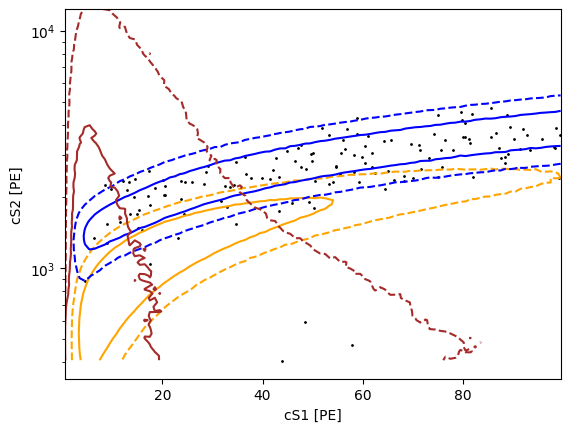

In [12]:
# Reproducing Fig. 3 (template distribution in cs1-cs2 space)
xenonnt_sr01_st.plot_signal_template(
    "xenonnt_sr1a",
    200,
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["orange", "orange"], "linestyles": ["--", "-"]},
)
xenonnt_sr01_st.plot_bkg_template(
    "xenonnt_sr1a",
    "er_flat",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["blue", "blue"], "linestyles": ["--", "-"]},
)
xenonnt_sr01_st.plot_bkg_template(
    "xenonnt_sr1a",
    "xenonnt_sr1_ac",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["brown", "brown"], "linestyles": ["--", "-"]},
)
data = xenonnt_sr01_st.experiment_instances[0].get_data()
plt.yscale("log")
plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
plt.xlabel("cS1 [PE]")
plt.ylabel("cS2 [PE]")

Text(0, 0.5, 'cS2 [PE]')

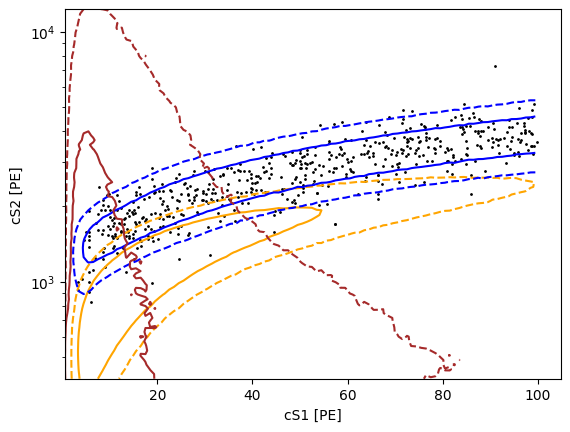

In [13]:
# Reproducing Fig. 3 (template distribution in cs1-cs2 space)
xenonnt_sr01_st.plot_signal_template(
    "xenonnt_sr1b",
    200,
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["orange", "orange"], "linestyles": ["--", "-"]},
)
xenonnt_sr01_st.plot_bkg_template(
    "xenonnt_sr1b",
    "er_flat",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["blue", "blue"], "linestyles": ["--", "-"]},
)
xenonnt_sr01_st.plot_bkg_template(
    "xenonnt_sr1b",
    "xenonnt_sr1_ac",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["brown", "brown"], "linestyles": ["--", "-"]},
)
data = xenonnt_sr01_st.experiment_instances[1].get_data()
plt.yscale("log")
plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
plt.xlabel("cS1 [PE]")
plt.ylabel("cS2 [PE]")

In [14]:
# Reproducing Table I (nominal & best-fit rate)
xenonnt_sr01_st.print_best_fit(200)

xenonnt_sr0
                   Nominal   Best fit
er                     134   135 ± 12
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
Signal best fit: 1.9548109003973666

xenonnt_sr1a
                     Nominal     Best fit
er_flat             430 ± 30     460 ± 30
tritium                   62      20 ± 30
ar37                  58 ± 6       53 ± 5
xenonnt_neutron  0.47 ± 0.19  0.47 ± 0.19
xenonnt_sr1_ac   2.12 ± 0.18  2.11 ± 0.18
Signal best fit: 1.3689842898681872

xenonnt_sr1b
                   Nominal   Best fit
er_flat           151 ± 11   157 ± 10
tritium                101    69 ± 17
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
xenonnt_sr1_ac   3.8 ± 0.3  3.8 ± 0.3
Signal best fit: 2.4645828281560913



Running inference: 100%|██████████| 90/90 [16:21<00:00, 10.90s/it]


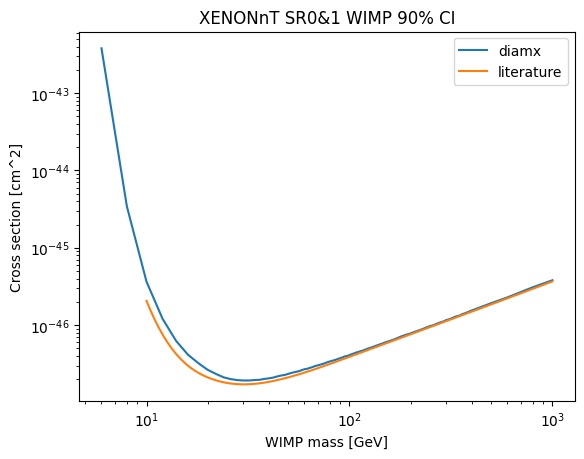

In [15]:
# Reproducing Fig. 5 (upper limit)roce
xenonnt_sr01_st.run_inference(output_file_name="xenonnt_sr1_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0&1 WIMP 90% CI")
# plt.savefig("xenonnt_sr1_wimp_ci.png", dpi=600)
plt.show()

## 4. LZ WS2024

arXiv:2410.17036

In [16]:
lz_ws2024_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2024_wimp_config.json"),
)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2024)
lz_ws2024_st.generate_templates()

/home/mhliu/miniconda3/envs/xenon/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Generating background templates for lz_ws2022: 100%|██████████| 6/6 [00:00<00:00, 2264.95it/s]
/home/mhliu/miniconda3/envs/xenon/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Generating shaped background templates for lz_ws2022: 0it [00:00, ?it/s]
Generating background templates for lz_ws2024: 100%|██████████| 8/8 [05:42<00:00, 42.75s/it] 
Generating shaped background templates for lz_ws2024: 100%|██████████| 12/12 [04:30<00:00, 22.58s/it]
Generating signal templates for lz_ws2024:  54%|█████▎    | 36/67 [11:43<11:45, 22.74s/it] WARNING: your position 

Text(0, 0.5, 'S2c [phd]')

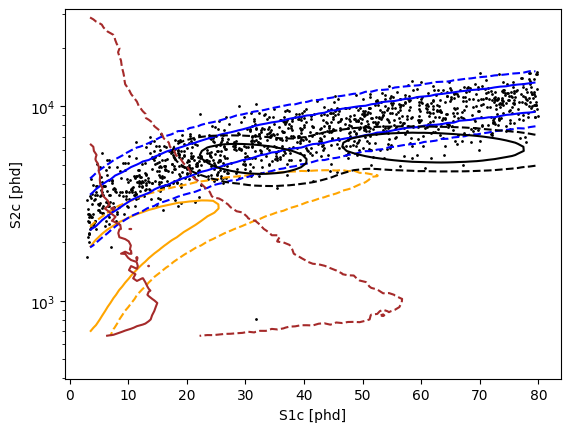

In [17]:
# Reproducing Fig. 3 (template distribution in cs1-cs2 space)
lz_ws2024_st.plot_signal_template(
    "lz_ws2024",
    40,
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["orange", "orange"], "linestyles": ["--", "-"]},
)
lz_ws2024_st.plot_bkg_template(
    "lz_ws2024",
    "pb214",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["blue", "blue"], "linestyles": ["--", "-"]},
)
lz_ws2024_st.plot_bkg_template(
    "lz_ws2024",
    "xe124",
    shape_parameter_value=71,
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["k", "k"], "linestyles": ["--", "-"]},
)
lz_ws2024_st.plot_bkg_template(
    "lz_ws2024",
    "ac",
    mode=["contour"],
    histogram_kwargs={"norm": LogNorm()},
    contour_kwargs={"colors": ["brown", "brown"], "linestyles": ["--", "-"]},
)
data = lz_ws2024_st.experiment_instances[1].get_data()
plt.yscale("log")
plt.ylim([10**2.6, 10**4.5])
plt.scatter(data["s1c"], data["s2c"], s=1, c="k")
plt.xlabel("S1c [phd]")
plt.ylabel("S2c [phd]")

In [20]:
# Reproducing Table I (nominal & best-fit rate)
lz_ws2024_st.print_best_fit(200)

lz_ws2022
             Nominal    Best fit
beta        220 ± 40    225 ± 16
neutrino  27.5 ± 1.6  27.5 ± 1.6
xe127      9.2 ± 0.8   9.3 ± 0.8
xe124      5.0 ± 1.4   5.3 ± 1.4
xe136         15 ± 2      15 ± 2
ar37              50      49 ± 9
Signal best fit: 0.0

lz_ws2024
                      Nominal   Best fit
pb214                740 ± 90   750 ± 40
kr85_ar39_detgamma   160 ± 20   160 ± 20
solar_neutrino_er     102 ± 6    102 ± 6
pb212_po218            63 ± 8     63 ± 7
tritium_c14            58 ± 3     58 ± 3
xe136                  56 ± 8     56 ± 8
xe127_xe125         3.2 ± 0.6  3.2 ± 0.6
ac                  2.8 ± 0.3  2.8 ± 0.3
xe124                  19 ± 4     22 ± 4
Shape parameters:
                               Nominal    Best fit
lz_ws2024_dec_quenching_factor      71  69.0 ± 1.4
Signal best fit: 0.0



Running inference: 100%|██████████| 67/67 [37:16<00:00, 33.38s/it]


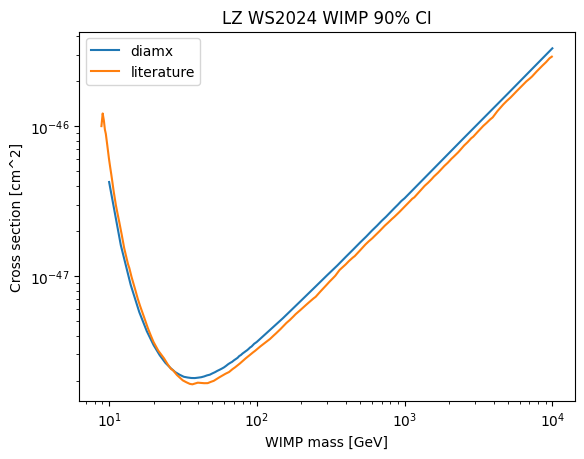

In [19]:
# Reproducing Fig. 5 (upper limit)
lz_ws2024_st.run_inference(output_file_name="lz_ws2024_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2024 WIMP 90% CI")
# plt.savefig("xenonnt_sr1_wimp_ci.png", dpi=600)
plt.show()